# Bab 4: Ekstraksi Fitur & Optimasi Model (FastText + SVM)

Notebook ini mendokumentasikan tahapan inti pemodelan yang memenuhi standar baku pelaporan Skripsi (Ilmu Komputer/Informatika).
Tahapan yang dilakukan:
1. **Feature Extraction (FastText)**: Mengubah teks menjadi representasi vektor numerik (300 dimensi) menggunakan model pratih `cc.id.300.bin`.
2. **K-Fold Cross Validation & Hyperparameter Tuning**: Tidak hanya menggunakan satu model SVM, kita akan melatih ratusan model dengan kombinasi parameter berbeda (Mencari nilai `C` dan `Kernel` terbaik) menggunakan algoritma `GridSearchCV` yang distandarisasi dengan 5-Fold Cross Validation.
3. **Pelatihan Model Terbaik (Best Estimator)**: Melatih model dengan parameter yang terbukti paling optimal.
4. **Evaluasi Akademik**: Mencetak Laporan Klasifikasi (*Precision, Recall, F1-Score*) dan menggambar matriks kebingungan (*Heatmap Confusion Matrix*).

In [25]:
import pandas as pd
import numpy as np
import fasttext
import pickle
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Konfigurasi Visualisasi Standar Jurnal
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 8)

## 4.1 Membaca Dataset & Pembersihan Teks Akhir

In [26]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

print("[LOG] Membaca dataset_labeled.csv...")
df = pd.read_csv('dataset_labeled.csv')
df = df.dropna(subset=['text', 'intent'])

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']

print(f"[LOG] Total dataset siap latih: {len(df)} baris.")
display(df.head())

[LOG] Membaca dataset_labeled.csv...
[LOG] Total dataset siap latih: 499 baris.


,text,intent,source,clean_text
0,Kira-kira servisnya butuh waktu berapa lama?,tanya_estimasi_waktu,synthetic,kirakira servisnya butuh waktu berapa lama
1,Ok otw,sapaan,real,ok otw
2,"batal servis komputer, mohon maaf",batal,synthetic,batal servis komputer mohon maaf
3,nanti sore saya ambil laptop nya,tanya_status,real,nanti sore saya ambil laptop nya
4,"gak jadi servis komputer, udah gak ada waktu",batal,synthetic,gak jadi servis komputer udah gak ada waktu


## 4.2 Ekstraksi Fitur FastText (Word Embeddings)

In [27]:
print("[LOG] Memuat FastText pre-trained model (cc.id.300.bin)...")
if not os.path.exists('cc.id.300.bin'):
    raise FileNotFoundError("cc.id.300.bin tidak ditemukan!")
    
ft_model = fasttext.load_model('cc.id.300.bin')
print("[LOG] FastText berhasil dimuat!")

def get_sentence_vector(text, ft_model):
    words = text.split()
    if not words:
        return np.zeros(ft_model.get_dimension())
    word_vectors = [ft_model.get_word_vector(w) for w in words]
    return np.mean(word_vectors, axis=0)

X = np.array([get_sentence_vector(t, ft_model) for t in df['clean_text']])
y = df['intent'].values

# Tampilkan Cuplikan Ekstraksi Fitur untuk Lampiran Skripsi
df_features = pd.DataFrame(X[:, :5], columns=['Dim_1', 'Dim_2', 'Dim_3', 'Dim_4', 'Dim_5'])
df_features.insert(0, 'intent', y)
df_features.insert(0, 'text', df['clean_text'])
print("\n[TABEL] Cuplikan Vektor Fitur (5 dari 300 dimensi):")
display(df_features.head())

[LOG] Memuat FastText pre-trained model (cc.id.300.bin)...
[LOG] FastText berhasil dimuat!

[TABEL] Cuplikan Vektor Fitur (5 dari 300 dimensi):


,text,intent,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5
0,kirakira servisnya butuh waktu berapa lama,tanya_estimasi_waktu,-0.020179,0.000017,0.049145,0.034191,0.022087
1,ok otw,sapaan,0.160384,0.145752,-0.067970,-0.004332,-0.020461
2,batal servis komputer mohon maaf,batal,0.031594,0.049462,0.041881,0.095924,-0.011591
3,nanti sore saya ambil laptop nya,tanya_status,0.029651,0.000212,-0.013197,0.121347,-0.003918
4,gak jadi servis komputer udah gak ada waktu,batal,0.043926,-0.015595,0.048213,0.097652,-0.003102


## 4.3 Pembagian Data (Train 80% : Test 20%)
Membagi data pengujian secara proporsional menggunakan metode *Stratified Sampling*.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"[LOG] Total Data Pembelajaran (Train): {len(X_train)} sampel")
print(f"[LOG] Total Data Pengujian (Test): {len(X_test)} sampel")

[LOG] Total Data Pembelajaran (Train): 399 sampel
[LOG] Total Data Pengujian (Test): 100 sampel


## 4.4 Hyperparameter Tuning dengan GridSearchCV (5-Fold CV)
Menguji beberapa kombinasi nilai penalti `C` dan `kernel` (Linear vs RBF) untuk menemukan akurasi tertinggi.

In [29]:
print("[LOG] Memulai proses Hyperparameter Tuning (GridSearchCV)...")
print("[LOG] Mencari kombinasi parameter terbaik dari: C=[0.1, 1, 10], kernel=['linear', 'rbf']")

# Parameter Grid yang akan diuji
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'class_weight': ['balanced']
}

# 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    verbose=2, # Akan mencetak log proses uji coba tiap parameter di layar
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n[HASIL] Hyperparameter Tuning Selesai!")
print(f"-> Parameter Terbaik: {grid_search.best_params_}")
print(f"-> Akurasi Cross-Validation Terbaik: {grid_search.best_score_ * 100:.2f}%")

# Mengambil model terbaik dari hasil GridSearch
best_svm_clf = grid_search.best_estimator_

[LOG] Memulai proses Hyperparameter Tuning (GridSearchCV)...
[LOG] Mencari kombinasi parameter terbaik dari: C=[0.1, 1, 10], kernel=['linear', 'rbf']
Fitting 5 folds for each of 8 candidates, totalling 40 fits

[HASIL] Hyperparameter Tuning Selesai!
-> Parameter Terbaik: {'C': 10, 'class_weight': 'balanced', 'kernel': 'rbf'}
-> Akurasi Cross-Validation Terbaik: 71.92%


## 4.5 Evaluasi Akhir (Laporan Klasifikasi & Confusion Matrix)

[LOG] Melakukan Prediksi pada Data Uji (Test Data)...

AKURASI MODEL AKHIR (TESTING): 71.00%

[TABEL] Laporan Klasifikasi Rinci (Precision, Recall, F1-Score):
                      precision    recall  f1-score   support

               batal       1.00      0.88      0.93         8
         butuh_admin       1.00      1.00      1.00         7
           info_toko       1.00      0.62      0.77         8
       klaim_garansi       1.00      1.00      1.00         7
            komplain       0.80      1.00      0.89         8
konsultasi_kerusakan       0.38      0.38      0.38         8
          nego_harga       0.62      0.62      0.62         8
              sapaan       0.50      0.71      0.59        14
              setuju       0.20      0.12      0.15         8
tanya_estimasi_waktu       0.88      0.88      0.88         8
        tanya_status       0.71      0.62      0.67         8
         umum_teknis       0.75      0.75      0.75         8

            accuracy             

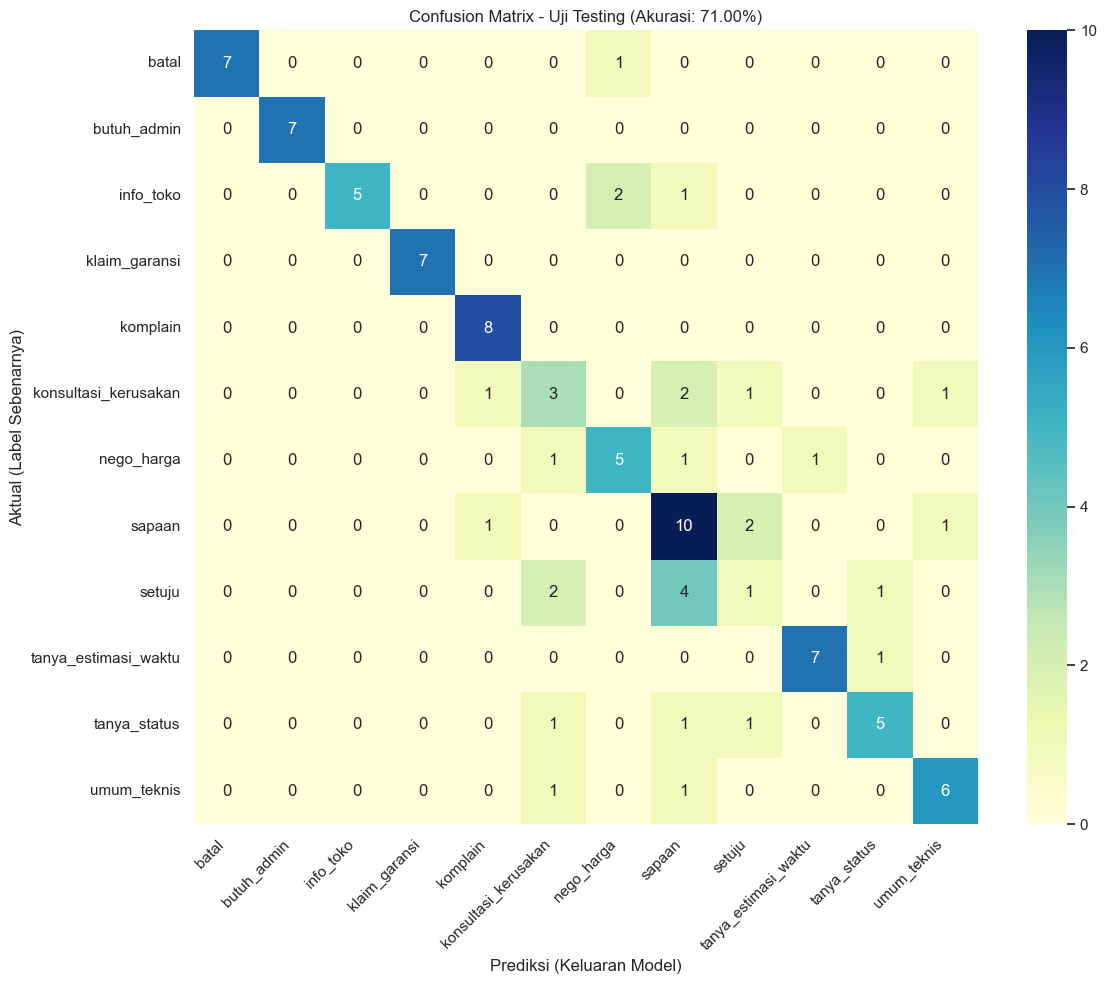

In [30]:
print("[LOG] Melakukan Prediksi pada Data Uji (Test Data)...")
y_pred = best_svm_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\n==========================================")
print(f"AKURASI MODEL AKHIR (TESTING): {acc:.2f}%")
print(f"==========================================\n")

print("[TABEL] Laporan Klasifikasi Rinci (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, zero_division=0))

print("[GRAFIK] Menggambar Heatmap Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred, labels=best_svm_clf.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=best_svm_clf.classes_, yticklabels=best_svm_clf.classes_)
plt.title(f'Confusion Matrix - Uji Testing (Akurasi: {acc:.2f}%)')
plt.xlabel('Prediksi (Keluaran Model)')
plt.ylabel('Aktual (Label Sebenarnya)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4.6 Simpan Model

In [31]:
model_filename = 'svm_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_svm_clf, f)
print(f"[LOG] Model SVM terbaik berhasil diekspor ke {model_filename}!")

[LOG] Model SVM terbaik berhasil diekspor ke svm_model.pkl!
